In [ ]:
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/sample_data/Q1_bioprinting_data.csv',header=None)

Question 1:

**from the paper:**

Within the dataset, null instances for bioink temperature (i.e., syringe temperature) and printing substrate temperature were set at 22 °C as the majority of experiments were conducted or were assumed to be conducted at room temperature.

Additional variables with more than 50% null values were removed from the dataset and non-printing instances were also removed (instances with cast molded bioink or other methods with cells cultured within non-extruded hydrogel). Variables with only null instances and instances of zero units were removed prior to model usage as available imputation methods of null values would not provide an accurate representation of actual quantitative values of the variables used in respective manuscripts.

Additional variables with null values and non-zero instances were imputed through k-nearest-neighbors imputing with a neighbor range of 30.

Categorical data was encoded through one-hot-encoding. Feature selection was performed by conducting feature importance analysis on variables within the cell viability and filament diameter datasets using random forest regression. For regression model performance evaluation, continuous variable instances were normalized through the MinMaxScaler function (Sci-kit Learn package, Python 3.7).

Handling missing values for bioink temperature as described in the paper

• Removing features with more than 50% missing or zero values

• Imputing remaining missing values using KNNImputer from scikit-learn

• Scaling continuous features using MinMaxScaler

• Removing “Acceptable Pressure” from the feature set

You may upload the dataset directly to your Google Colab session and use libraries such as pandas and
scikit-learn for preprocessing.
Submit your preprocessing code

Handling missing values for bioink temperature as described in the paper

In [ ]:
df[36] = df[36].fillna(22)

Removing features with more than 50% missing or zero values

In [ ]:
num_of_rows = len(df) - 1
df = df.dropna(axis=1, thresh=(num_of_rows-1)*0.5)
df = df.loc[:, (df != 0).any()]
df = df.drop(1, axis=1)
df = df.drop(0, axis=1)

Imputing remaining missing values using KNNImputer from scikit-learn

In [ ]:
df = df[1:]
pd.set_option('future.no_silent_downcasting', True)
df = df.replace({'Y': 1, 'N': 0})
df = df.replace({'S': 1, 'C': 0})
df = df.replace({'Primary': 1, 'Not_Primary': 0})
df = df.convert_dtypes()
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=30)
df = imputer.fit_transform(df)


Scaling continuous features using MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df = pd.DataFrame(df)
df = df.select_dtypes(include=['float'])
df = scaler.fit_transform(df)
df = pd.DataFrame(df)

Removing “Acceptable Pressure” from the feature set

In [ ]:
df = df.drop(44, axis=1)
df = df.drop(42, axis=1)

In [ ]:
print(df)

         0     1    2    3    4    5    6    7    8    9   ...   33   34   35  \
0    0.1000  0.00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1    0.1000  0.00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2    0.1000  0.00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3    0.0000  0.00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4    0.0000  0.00  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
..      ...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
612  0.1875  0.08  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0   
613  0.1875  0.08  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0   
614  0.2000  0.08  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0   
615  0.2000  0.08  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0   
616  0.2000  0.08  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0   

      36   37   38   39   4

  Question 2

Test accuracy:  0.7741935483870968
Test precision 0.7441860465116279
Test recall 0.9142857142857143


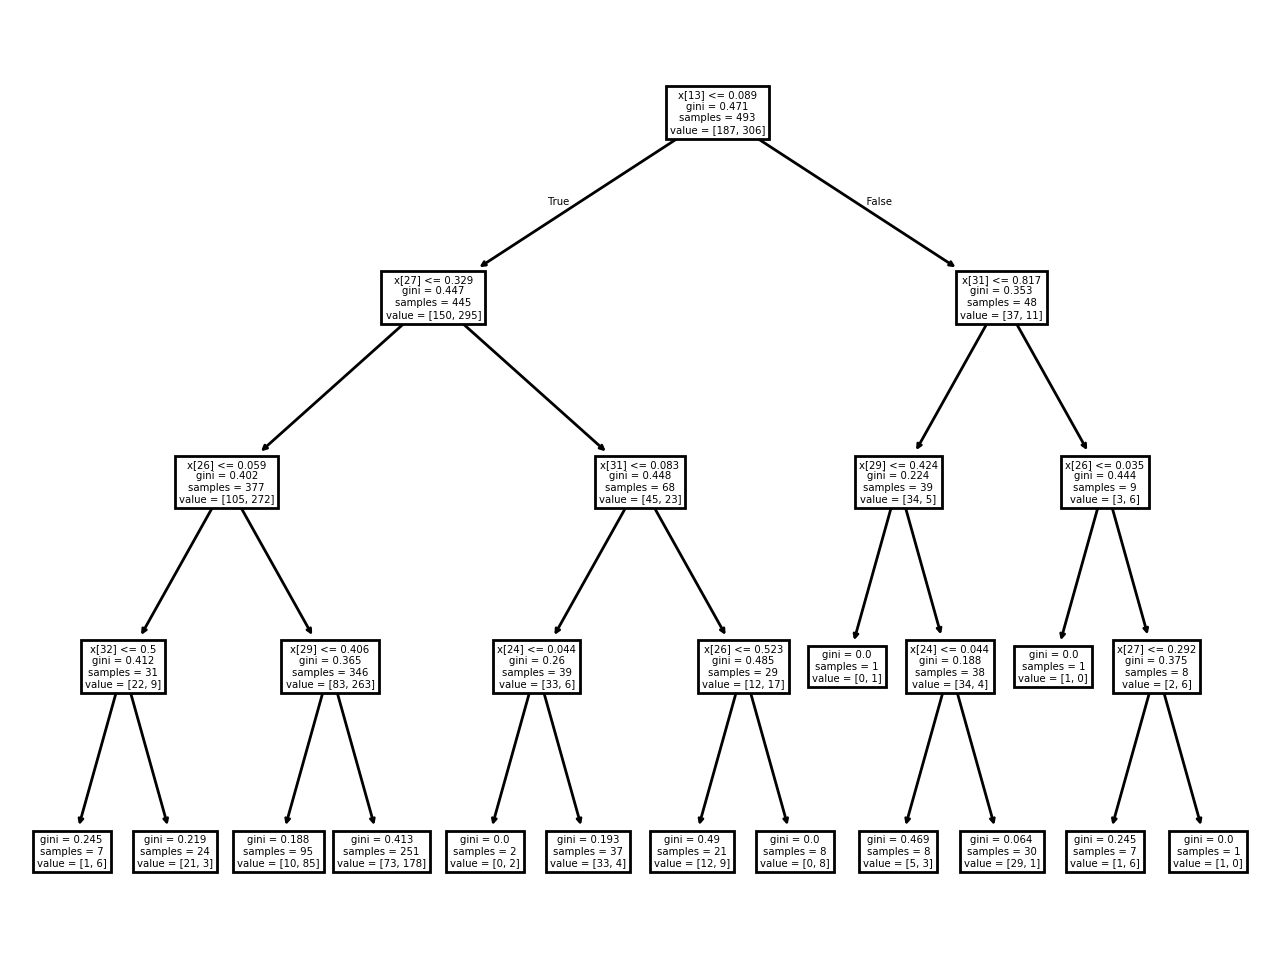

In [ ]:
clf = tree.DecisionTreeClassifier(max_depth=4)

X = df.drop(columns=[43])
y = df[43]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1,shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.11, random_state=1,shuffle=True)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
TN = np.sum(np.logical_and(y_pred == 0, y_test == 0))
TP = np.sum(np.logical_and(y_pred == 1, y_test == 1))
FN = np.sum(np.logical_and(y_pred == 0, y_test == 1))
FP = np.sum(np.logical_and(y_pred == 1, y_test == 0))
print("Test accuracy: ", (TN+TP)/(TN+TP+FN+FP))
print("Test precision", (TP)/(TP+FP))
print("Test recall", (TP)/(TP+FN))
plt.figure(figsize=(8, 6), dpi=200)
tree.plot_tree(clf)
plt.savefig('tree')

Question 3 (SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

X_SVM = df.drop(columns=[43])
y_svm = df[43]

X_train, X_test, y_train, y_test = train_test_split(X_SVM, y_svm, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.11, random_state=1,shuffle=True)

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred = clf.predict(X_test)
TN = np.sum(np.logical_and(y_pred == 0, y_test == 0))
TP = np.sum(np.logical_and(y_pred == 1, y_test == 1))
FN = np.sum(np.logical_and(y_pred == 0, y_test == 1))
FP = np.sum(np.logical_and(y_pred == 1, y_test == 0))
print("Test accuracy: ", (TN+TP)/(TN+TP+FN+FP))
print("Test precision", (TP)/(TP+FP))
print("Test recall", (TP)/(TP+FN))

Test accuracy:  0.7903225806451613
Test precision 0.7862595419847328
Test recall 0.9035087719298246
